# Spherical Harmonics Processing

Spherical harmonics are orthogonal spherical basis functions that have many use cases in acoustics signal processing. Most notably, the real-valued spherical harmonics are the basis of Ambisonics sound field capture and reproduction systems used in many immersive audio formats. But more generally, spherical harmonics are used to describe, analyze, interpolate, and extrapolate sound fields. Examples for this are estimating the direction of arrival, diffuseness, or directional decay time of sound fields in rooms.

In this notebook, we will look at another common use case: the representation, interpolation and rotation of so called head-related transfer functions (HRTFs). These transfer functions describe the sound propagation from a free field sound source to the left and right ear of a listener. HRTFs are fundamental for immersive audio rendering via headphones and are usually measured for sound sources distributed on a spherical sampling grid - which makes it natural to describe and process them in the spherical harmonic domain.

We will use the [spharpy](https://spharpy.readthedocs.io/) Python package for spherical harmonic processing and take HRTF processing as a chance to introduce core concepts of spharpy and [pyfar](https://pyfar.org). For a complete documentation of the related packages and more examples, please visit [pyfar.org](https://pyfar.org).

We recommend to visit the Notebooks about pyfar [audio](https://pyfar-gallery.readthedocs.io/en/latest/gallery/interactive/pyfar_audio_objects.html) and [coordinate](https://pyfar-gallery.readthedocs.io/en/latest/gallery/interactive/pyfar_coordinates.html) objects, and the Notebook about [binaural synthesis](https://pyfar-gallery.readthedocs.io/en/latest/gallery/static/binaural_synthesis.html) before continuing. We are also assuming that you are familiar with the basic concepts of spherical harmonics, which are for example detailed in [1] and [2].

[1] Rafaely, B. (2019). Fundamentals of spherical array processing (2nd ed.). Springer. https://doi.org/10.1007/978-3-319-99561-8

[2] Zotter, F., & Frank, M. (2019). Ambisonics. A practical 3D audio theory for recording, studio production, sound reinforcement, and virtual reality (Vol. 19). Springer Open. https://doi.org/10.1007/978-3-030-17207-7



In [ ]:
import spharpy
import pyfar as pf
import numpy as np
import matplotlib.pyplot as plt
import pooch
%matplotlib inline

## Load HRTFs

Lets first load an HRTF data set as a pyfar *Signal* and the source positions as a pyfar *Coordinates* object. The code below, downloads a publicly available HRTF dataset and loads it into the variables `hrirs` and `sources`.

In [ ]:
# adjust this path to your needs. Using `None` will download the file to your
# system cache.
path = None

# Leave this as it is: This is the URL from which the data will be downloaded
# and a hash for checking if the download worked.
url = 'https://github.com/pyfar/files/raw/refs/heads/main/education/VAR_TUB/FABIAN_HRIR_measured_HATO_0.sofa?download='
hash = '83ebbcd9a09d17679b95d201c9775438c0bb1199d565c3fc7a25448a905cdc3c'

file = pooch.retrieve(
    url, hash, fname='FABIAN_HRIR_measured_HATO_0.sofa', path=path)

# load HRIRs and source positions
hrirs, sources, _ = pf.io.read_sofa(file)

## Inspect HRTFs and Source Positions

Lets quickly inspect the data, we are working with by looking at the channel shape (`cshape`) of the loaded objects. The Signal contains HRIRs for $Q=11950$ source positions and $2$ ears (the left ear data is contained in `hrirs[:, 0]`, and the right ear data in `hrirs[:, 1]`)

In [ ]:
hrirs.cshape

Accordingly, $11950$ source positions are stored in the Coordinates object

In [ ]:
sources.cshape

A quick plot of the source positions shows that they all have the same radius and represent a full-spherical sampling grid

In [ ]:
sources.show()
plt.show()

Because all source positions have the same radius, we can store them in a spharpy [SamplingSphere](https://spharpy.readthedocs.io/en/stable/classes/spharpy.coordinates.html) object.

In [ ]:
sources = spharpy.SamplingSphere.from_coordinates(sources)

## Background

To represent the HRTFs in the spherical harmonic domain, we interpret it as a spherical function

$$\mathbf{h} = [h_1, h_2, ..., h_Q]^\mathrm{T}$$

that represents a single sample of the HRIR or a single frequency bin of the HRTF for one ear and **all** $Q$ source positions.

We can apply the spherical harmonic transform - also referred to as spherical Fourier transform - to $\mathbf{f}$ to get the spherical harmonic spectrum

$$\mathrm{h}_{nm} = \mathbf{Y}^\dagger \, \mathbf{h} = [h_{0,0}, h_{1,-1}, h_{1,-1}, h_{1,-1}, ..., , h_{N,N}]^\mathrm{T}$$

that contains the $(N+1)^2$ spherical harmonic coefficients for each order $n$ and degree $m$ up to the maximum spherical harmonic order $N$.

In the above $\mathbf{Y}$ denotes the matrix containing the spherical harmonic basis functions $Y_n^m$ and $(\cdot)^\dagger$ is the pseudo inverse

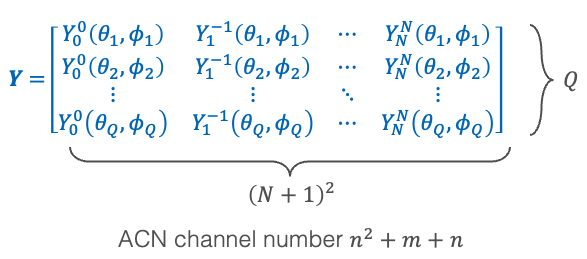

As you can see, $\mathbf{Y}$ it is of shape $Q$ $\times$ $(N+1)^2$, and basis functions depend on the colatitude $\theta$ and the azimuth $\phi$ of the source positions. 

Once $\mathrm{h}_{nm}$ was computed, it can be used to estimate the HRTFs at any source position $\hat{\theta}$, $\hat{\phi}$ by means of the inverse spherical harmonic transform

$$\hat{\mathbf{h}} = \mathbf{Y} \, \mathbf{h}_{nm}$$

in this case using

$$\mathrm{Y} = [Y_0^0(\hat{\theta},\hat{\phi}), Y_1^{-1}(\hat{\theta},\hat{\phi}), Y_1^0(\hat{\theta},\hat{\phi}), Y_1^1(\hat{\theta},\hat{\phi}), ..., Y_N^N(\hat{\theta},\hat{\phi})].$$

Because $\mathrm{h}$ contains data for a single sample or frequency bin, the above is done separately for *each* sample or frequency bin.

## Spherical Harmonic Definition

Before computing $\mathrm{Y}$ and its pseudo inverse, we need to decide on the maximum spherical harmonic order and the spherical harmonic definition.

The sampling grid supports spherical harmonic processing up to an order of approximately $N=32$ and for simplicity, we use the default spherical harmonic definition of spharpy.

The below creates a [SphericalHarmonicDefinition](https://spharpy.readthedocs.io/en/stable/theory/spherical_harmonic_definition.html) object that conveniently documents, how the used spherical harmonics are defined.

In [ ]:
# specify sh order and definition
n_max = 16
sh_definition = spharpy.SphericalHarmonicDefinition(n_max)

print(f'{sh_definition.basis_type = }')
print(f'{sh_definition.normalization = }')
print(f'{sh_definition.condon_shortley = }')
print(f'{sh_definition.channel_convention = }')
print(f'{sh_definition.n_max = }')

## Spherical Harmonic Matrix

We can now create a *SphericalHarmonics* object.

In [ ]:
sh = spharpy.SphericalHarmonics.from_definition(
    sh_definition, sources, inverse_method="pseudo_inverse")

Among other properties, it provides the spherical harmonic basis matrix $\mathbf{Y}$

In [ ]:
sh.basis.shape

and its pseudo inverse

In [ ]:
sh.basis_inv.shape

These matrices are computed upon request and are stored inside the SphericalHarmonics objects to speed up computations that involve multiple usages of the matrices. If any property of the SphericalHarmonic objects changes, for example if you set a different maximum spherical harmonic order, the matrices will be recomputed upon requiest.

For illustration, the below shows the real valued spherical harmonic basis functions up to order $N = 2$

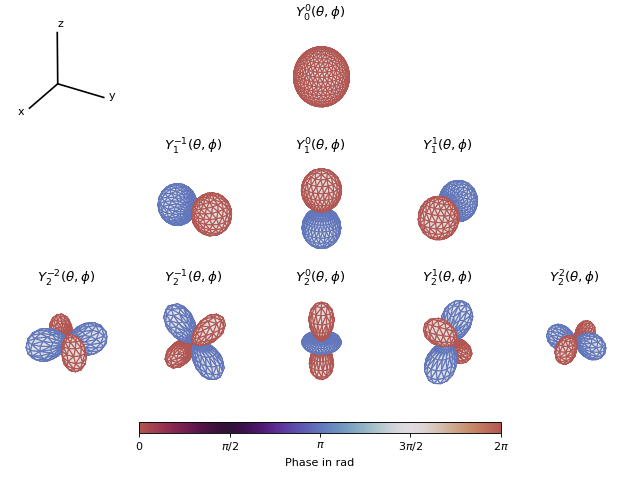

## Spherical Harmonics Transform

We can now compute $\mathrm{h}_{nm} = \mathbf{Y}^\dagger \, \mathbf{h}$. We do this with a single [pyfar.matrix_multiplication](https://pyfar.readthedocs.io/en/stable/classes/pyfar.audio.html#pyfar.matrix_multiplication) that performs the transform for all samples and both ears.

In this case, we perform the transform in the time domain. Because the Fourier transform and spherical harmonic transform are linear operations, we could as well perform the transform in the frequency domain.

In [ ]:
hrirs_nm = pf.matrix_multiplication((sh.basis_inv, hrirs), domain='time').T
print(type(hrirs_nm))
print(f'{hrirs_nm.cshape = }')
print(f'{hrirs_nm.n_samples = }')

The above yields a pyfar Signal object. It has two channels (left and right ear), $(N+1)^2$ (`(n_max+1)**2`) spherical harmonic coefficients, and 256 samples. Lets convert it to a *SphericalHarmonicSignal*, which conveniently stores the spherical harmonic data and sampling rate along with the spherical harmonic definition.

**Note:** spharpy v1.1 will have a function to do the spherical harmonic transform that will directly return a SphericalHarmonicSignal.

In [ ]:
hrirs_nm = spharpy.SphericalHarmonicSignal.from_definition(
    sh_definition, hrirs_nm.time, hrirs_nm.sampling_rate)
print(f'{hrirs_nm.cshape = }')
print(f'{hrirs_nm.n_max = }')

For illustration, lets plot the left and right ear spherical harmonic signal of order 1 and degree 1. This is contained in `hrirs_nm[:, 1]` and contains the 'left/right'-component of the HRTF data set.

In [ ]:
ax = pf.plot.time_freq(hrirs_nm[:, 1], label=['left ear', 'right ear'])
ax[1].legend()
plt.show()

## Spherical Harmonic Rotation

A common processing is sound field rotation in the spherical harmonic domain. One use case in Ambisonics is to rotate the sound field to counter head rotations of the listener during headphone playback. This creates a naturally stable sound scene that the listener can explore with head rotations.

Mathematically, this realized by a matrix multiplication with a rotation matrix

$$\mathbf{h}_{nm,\mathrm{rot}} = \mathbf{R} \, \mathbf{h}_{nm}$$

In spharpy, arbitrary rotations can be applied with the [SphericalHarmonicRotation](https://spharpy.readthedocs.io/en/stable/modules/spharpy.transforms.html#spharpy.transforms.SphericalHarmonicRotation) class. Lets create a rotation by 45 degrees about the z-axis.

In [ ]:
rotation = spharpy.transforms.SphericalHarmonicRotation.from_euler(
    'z', [np.pi / 4])

One way to apply the rotation would be generate the rotation matrix using

`R = rotation.as_spherical_harmonic_matrix(sh_definition)`

In this example we will directly use the SphericalHarmonicRotation object and the SphericalHarmonicSignal

In [ ]:
hrirs_nm_rotated = rotation.apply(hrirs_nm)

## Inverse Spherical Harmonic Transform

We now perform the inverse transform introduced above

$$\hat{\mathbf{h}} = \mathbf{Y} \, \mathbf{h}_{nm} . $$

Note two things:

1. If $N$ is sufficently large, we get $\hat{\mathbf{h}} = \mathbf{h}$ after applying the inverse transform. HRTFs require $N>32$, which means that you will see differences between $\hat{\mathbf{h}}$ and $\mathbf{h}$ 
2. In the example below $\mathbf{Y}$ contains the source positions of the original HRTF data set. In general, it can contain one or multiple arbitrary source positions.

Again, the transform for all time samples can be done with a single call of [pyfar.matrix_multiplication](https://pyfar.readthedocs.io/en/stable/classes/pyfar.audio.html#pyfar.matrix_multiplication).

In [ ]:
print(sh.basis.shape)
print(hrirs_nm.time.shape)

In [ ]:
# obtain HRIRs using the inverse SH transform
hrirs_sh = pf.matrix_multiplication(
    (sh.basis, hrirs_nm), domain='time', axes=[(0, 1), (1, 0), (0, 1)])
hrirs_sh = pf.Signal(hrirs_sh, hrirs.sampling_rate)

# obtain rotated HRIRs using the inverse SH transform
hrirs_sh_rotated = pf.matrix_multiplication(
    (sh.basis, hrirs_nm_rotated), domain='time', axes=[(0, 1), (1, 0), (0, 1)])
hrirs_sh_rotated = pf.Signal(hrirs_sh_rotated, hrirs.sampling_rate)

hrirs_sh.cshape

Note that we manually stored the data in a pyfar Signal object after the inverse transform. Starting in spharpy v1.1, there will be a function that performs the transform and directly returns a Signal object.

## Plot the Results

### Single HRTF

Lets first plot a single HRTF before and after the spherical harmonic processing.

In [ ]:
# source position for plotting
find = pf.Coordinates.from_spherical_colatitude(
    90 / 180 * np.pi,  # azimuth angle
    90 / 180 * np.pi,  # colatitude angle
    1.7)               # radius
idx, _ = sources.find_nearest(find)
idx = idx[0]

# plot
ax = pf.plot.freq(
    hrirs[idx], label=['original: left', 'original:right'])
pf.plot.freq(
    hrirs_sh[idx], ls="--", label=['processed: left', 'processed: right'])

ax.set_ylim(-25, 25)
ax.legend(loc='lower left')
plt.show()

As mentioned above, you can see that the spherical harmonic processing introduced errors to the HRTF.

### Plot single Frequency

In [ ]:
frequency = 1000
idx = hrirs_sh.find_nearest_frequency(frequency)

pf.plot.use()
fig, axes = plt.subplots(2,1, subplot_kw={'projection': 'mollweide'})

axes[0].set_title('Left ear processed HRTF (no rotation)')
axes[0].grid(True)
spharpy.plot.pcolor_map(
    sources, 20 * np.log10(np.abs(hrirs_sh.freq[:, 0, idx])),
    ax=axes[0])

axes[1].set_title('Left ear processed HRTF (45 deg. rotation)')
axes[1].grid(True)
spharpy.plot.pcolor_map(
    sources, 20 * np.log10(np.abs(hrirs_sh_rotated.freq[:, 0, idx])),
    ax=axes[1])

plt.show()

## Exploration

Now that you have coded all the above, it's time to play. For example, you can try to the processing with different spherical harmonic orders to see how the order affects the results. You could also render the HRTFs and listen to the result via headphones. An example for this is given in the [binaural synthesis](https://pyfar-gallery.readthedocs.io/en/latest/gallery/static/binaural_synthesis.html) notebook.

# License notice

This notebook is licensed under CC BY 4.0

# Watermark

The following watermark might help others to install specific package versions that might be required to run the notebook. Please give at least the versions of Python, IPython, numpy , and scipy, major third party packagers (e.g., pytorch), and all used pyfar packages.

In [ ]:
%load_ext watermark
%watermark -v -m -p numpy,scipy,pyfar,sofar,nbgrader,watermark